## Preparation

In [ ]:
# TODO: Download pretrained weights to 'checkpoints/mae_visualize_vit_large_0.5gan_2.0bound_1.5percep.pth'
# TODO: Download pretrained weights to 'checkpoints/disc_vit_small_patch16_224_0.5gan_2.0bound_1.5percep.pth'
# Use the link below and download both weights in the 'mae_iprompt' folder.
# https://utoronto-my.sharepoint.com/:f:/r/personal/mingjie_zhao_mail_utoronto_ca/Documents/CSC2541/checkpoints?csf=1&web=1&e=E4KnDL

# TODO: Set dataset root directory. The images should be directly under the root directory.
IMAGE_PATH = "datasets/VOCdevkit/VOC2012/JPEGImages/"

# TODO: Set number of epochs
EPOCHS = 1

In [1]:
import os
from tqdm import tqdm
import numpy as np
# visualization
import matplotlib.pyplot as plt
from PIL import Image
# sklearn
from sklearn.model_selection import train_test_split
# pytorch
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MEAN = np.array([0.485, 0.456, 0.406])
STD = np.array([0.229, 0.224, 0.225])
TRAIN_SIZE = 0.8
IMG_SIZE = 224
BATCH_SIZE = 32

## Dataset

In [ ]:
# get the list of all image paths
paths = [os.path.join(IMAGE_PATH, f) for f in os.listdir(IMAGE_PATH)]
# split paths into training and testing
paths_train, paths_test = train_test_split(
    paths, train_size=TRAIN_SIZE, random_state=484
)

In [ ]:
# dataset class
class IPromptDataset(Dataset):
    def __init__(self, paths, prompt_transform=None, response_transform=None):
        self.paths = paths
        self.prompt_transform = prompt_transform
        self.response_transform = response_transform
    
    def __len__(self):
        return len(self.paths)
    
    def __getitem__(self, idx):
        response1 = Image.open(self.paths[idx])
        response2 = Image.open(self.paths[torch.randint(0,len(self.paths),(1,))])

        if self.response_transform:
            response1 = self.response_transform(response1)
            response2 = self.response_transform(response2)
        
        if self.prompt_transform:
            i = torch.randint(0, len(self.prompt_transform), (1,))
            p_transform = self.prompt_transform[i]  # apply random prompt transform
            try:
                response = torch.cat((response1, response2), dim=0)
                # apply the same prompt transformation
                prompt = p_transform(response)
                prompt1 = prompt[:3,:,:]
                prompt2 = prompt[3:,:,:]
            except:
                prompt1 = p_transform(response1)
                prompt2 = p_transform(response2)
        else:
            prompt1 = response1
            prompt2 = response2
        top_row = torch.cat((prompt1, response1), dim=2)  # [N, 112, 224, 3]
        bottom_row = torch.cat((prompt2, response2), dim=2)  # [N, 112, 224, 3]
        combined_image = torch.cat((top_row, bottom_row), dim=1)  # [N, 224, 224, 3]
        return combined_image

In [ ]:
# data augmentation
# TODO: change prompt augmentations
train_prompt_transform = [
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomErasing(p=1.0, scale=(0.05, 0.05), ratio=(1.0, 1.0)),
    transforms.GaussianBlur(5, sigma=2.0)
]
train_response_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(IMG_SIZE//2),
    transforms.RandomCrop(IMG_SIZE//2),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, hue=0.1)
    # transforms.Normalize(MEAN, STD)
])
test_prompt_transform = [
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomErasing(p=1.0, scale=(0.05, 0.05), ratio=(1.0, 1.0)),
    transforms.GaussianBlur(5, sigma=2.0)
]
test_response_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(IMG_SIZE//2),
    transforms.RandomCrop(IMG_SIZE//2)
    # transforms.Normalize(MEAN, STD)
])

# configure datasets
train_dataset = IPromptDataset(paths_train, train_prompt_transform, train_response_transform)
test_dataset = IPromptDataset(paths_test, test_prompt_transform, test_response_transform)

train_dataloader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True
)
test_dataloader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)

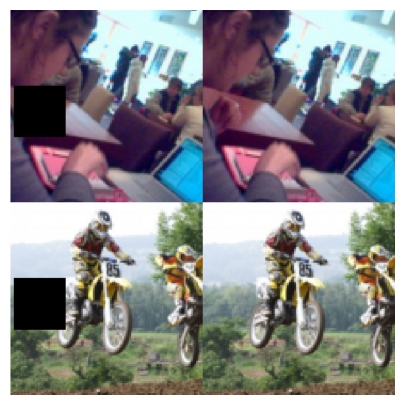

In [21]:
sample = next(iter(train_dataloader))[0]
plt.imshow(sample.permute(1, 2, 0).numpy())
plt.axis('off')

## Training Loop

In [ ]:
# train GAN, discriminator predicts real/fake over the entire image
def train_mae_ganpercep(
        models, dataloader, optimizers, epochs, checkpoint_paths, mask_ratio=0.75,
        alpha_gan_image=0.2, alpha_gan_patch=0.2, alpha_percep=0.6
    ):
    # unpack input
    generator, discriminator, percep = models
    generator_optimizer, discriminator_optimizer = optimizers
    checkpoint_path_g, checkpoint_path_d = checkpoint_paths
    # losses for each epoch
    generator_losses, discriminator_losses, recon_losses = [], [], []
    patch_size = generator.patch_embed.patch_size[0]
    for epoch in range(epochs):
        print('-'*10)
        print(f'Epoch {epoch + 1}/{epochs}:')
        generator.train()
        discriminator.train()
        generator_loss, discriminator_loss, recon_loss = 0.0, 0.0, 0.0
        i = 1
        for x in tqdm(dataloader):
            if i <= 0:
                break
            i -= 1
            x = x.to(DEVICE).float()
            ### Discriminator ###
            discriminator_optimizer.zero_grad()
            # generate fake data
            loss_recon, pred_x, mask = generator(x, mask_ratio, mask_mode='lower_right')
            fake_x = generator.unpatchify(pred_x)
            # replace visible patches with ground truth
            mask = mask.detach()
            mask_x = mask.unsqueeze(-1).repeat(1, 1, patch_size**2 *3)  # (N, H*W, p*p*3)
            mask_x = generator.unpatchify(mask_x)  # 1 is removing, 0 is keeping
            fake_x = mask_x * fake_x + (1-mask_x) * x  # replace visible patches with ground truth
            # pass fake data through discriminator
            targets_i = torch.zeros((x.shape[0],), dtype=torch.float, device=DEVICE)
            targets_p = 1-mask
            output_i, output_p = discriminator(fake_x.detach())
            loss_d_fake = alpha_gan_image * discriminator.criterion(output_i, targets_i) 
            loss_d_fake += alpha_gan_patch * discriminator.criterion(output_p, targets_p)
            loss_d_fake.backward()
            # pass real data through discriminator
            targets_i = torch.ones((x.shape[0],), dtype=torch.float, device=DEVICE)
            targets_p = torch.ones(mask.shape[0], mask.shape[1], device=DEVICE)
            output_i, output_p = discriminator(x)
            loss_d_real = alpha_gan_image * discriminator.criterion(output_i, targets_i) 
            loss_d_real += alpha_gan_patch * discriminator.criterion(output_p, targets_p)
            loss_d_real.backward()
            # compute error for discriminator
            loss_d = loss_d_fake + loss_d_real
            discriminator_loss += loss_d.item()
            # update discriminator
            discriminator_optimizer.step()
            ### Generator ###
            generator_optimizer.zero_grad()
            # pass fake data through generator and discriminator
            targets_i = torch.ones((x.shape[0],), dtype=torch.float, device=DEVICE)
            targets_p = mask
            output_i, output_p = discriminator(fake_x)
            loss_g_fake = alpha_gan_image * discriminator.criterion(output_i, targets_i) 
            loss_g_fake += alpha_gan_patch * discriminator.criterion(output_p, targets_p)
            # compute perceptual loss between real and fake
            loss_percep = percep(x, fake_x)
            loss_g = loss_g_fake + alpha_percep * 0 + loss_recon
            loss_g.backward()
            # compute error for generator
            generator_loss += loss_g.item()
            recon_loss += loss_recon.item()
            # update generator
            generator_optimizer.step()

        epoch_recon_loss = recon_loss / len(dataloader)
        epoch_generator_loss = generator_loss / len(dataloader)
        epoch_discriminator_loss = discriminator_loss / len(dataloader) / 2
        recon_losses.append(epoch_recon_loss)
        generator_losses.append(epoch_generator_loss)
        discriminator_losses.append(epoch_discriminator_loss)
        print('Train reconstruction loss:', round(epoch_recon_loss, 4))
        print('Train generator loss:', round(epoch_generator_loss, 4))
        print('Train discriminator loss:', round(epoch_discriminator_loss, 4))
        
    # save final models
    torch.save(
        {'epoch': epoch,
         'model': generator.state_dict(),
         'optimizer': generator_optimizer.state_dict(),
         'loss': epoch_generator_loss},
        checkpoint_path_g
    )
    torch.save(
        {'epoch': epoch,
         'model': discriminator.state_dict(),
         'optimizer': discriminator_optimizer.state_dict(),
         'loss': epoch_discriminator_loss},
        checkpoint_path_d
    )
    return generator_losses, discriminator_losses, recon_losses

In [8]:
def test_mae_ganpercep(model, dataloader, mask_ratio=0.75):
    # losses for each epoch
    running_loss = 0.0
    model.eval()
    with torch.no_grad():
        for x in dataloader:
            x = x.to(DEVICE).float()
            loss, pred, mask = model(x, mask_ratio)
            running_loss += loss.item()
    loss = running_loss / len(dataloader)
    print('Test loss:', round(loss, 4))
    return loss

## Training

In [10]:
# build MAE encoder and generator
import models_mae

arch = 'mae_vit_large_patch16'
generator = getattr(models_mae, arch)()

# load model
generator_path = 'checkpoints/mae_visualize_vit_large_0.5gan_2.0bound_1.5percep.pth'
checkpoint = torch.load(generator_path)
generator.load_state_dict(checkpoint['model'], strict=False)

<All keys matched successfully>

In [11]:
# freeze MAE encoder
for param in generator.patch_embed.parameters():
    param.requires_grad = False
generator.cls_token.requires_grad = False
generator.pos_embed.requires_grad = False
for param in generator.blocks.parameters():
    param.requires_grad = False
for param in generator.norm.parameters():
    param.requires_grad = False

generator = generator.to(DEVICE)

generator_optimizer = torch.optim.Adam(generator.parameters(), lr=1e-4, weight_decay=0.0)
# generator_optimizer.load_state_dict(checkpoint['optimizer'])

In [12]:
# build ViT discriminator
from models_disc import GANDiscriminator

discriminator = GANDiscriminator('vit_small_patch16_224')

# load model
discriminator_path = 'checkpoints/disc_vit_small_patch16_224_0.5gan_2.0bound_1.5percep.pth'
checkpoint = torch.load(discriminator_path)
discriminator.load_state_dict(checkpoint['model'], strict=False)

<All keys matched successfully>

In [13]:
discriminator = discriminator.to(DEVICE)

discriminator_optimizer = torch.optim.Adam(discriminator.parameters(), lr=1e-4, weight_decay=0.0)
# discriminator_optimizer.load_state_dict(checkpoint['optimizer'])

In [ ]:
from models_percep import PerceptualLoss

percep = PerceptualLoss().to(DEVICE)

In [ ]:
# train MAE-GANBound-Percep
torch.random.seed()
mae_gan_losses = train_mae_ganpercep(
    models=(generator, discriminator, percep),
    dataloader=train_dataloader,
    optimizers=(generator_optimizer, discriminator_optimizer),
    epochs=EPOCHS,
    checkpoint_paths=(generator_path, discriminator_path),
    mask_ratio=0.75,
    alpha_gan_image=0.5, alpha_gan_patch=0.5, alpha_percep=1.5
)

## Visualization

In [13]:
def show_image(image, title=''):
    # image is [H, W, 3]
    assert image.shape[2] == 3
    # plt.imshow(torch.clip((image * STD + MEAN) * 255, 0, 255).int())
    plt.imshow(torch.clip(image * 255, 0, 255).int())
    plt.title(title, fontsize=16)
    plt.axis('off')
    return

def run_one_image(img, model, mask_ratio=0.75):
    x = torch.tensor(img, device=DEVICE)

    # make it a batch-like
    x = x.unsqueeze(dim=0)
    x = torch.einsum('nhwc->nchw', x)

    # run MAE
    model = model.to(DEVICE)
    loss, y, mask = model(x.float(), mask_ratio=mask_ratio, mask_mode='lower_right')
    y = model.unpatchify(y)
    y = torch.einsum('nchw->nhwc', y).detach().cpu()

    # visualize the mask
    mask = mask.detach()
    mask = mask.unsqueeze(-1).repeat(1, 1, model.patch_embed.patch_size[0]**2 *3)  # (N, H*W, p*p*3)
    mask = model.unpatchify(mask)  # 1 is removing, 0 is keeping
    mask = torch.einsum('nchw->nhwc', mask).detach().cpu()
    
    x = torch.einsum('nchw->nhwc', x).detach().cpu()

    # masked image
    im_masked = x * (1 - mask)

    # MAE reconstruction pasted with visible patches
    im_paste = x * (1 - mask) + y * mask

    # make the plt figure larger
    plt.rcParams['figure.figsize'] = [24, 24]

    plt.subplot(2, 2, 1)
    show_image(x[0], "original")

    plt.subplot(2, 2, 2)
    show_image(im_masked[0], "masked")

    plt.subplot(2, 2, 3)
    show_image(y[0], "reconstruction")

    plt.subplot(2, 2, 4)
    show_image(im_paste[0], "reconstruction + visible")

In [36]:
def resize_crop(img, dim):
    # resize and preserve aspect ratio
    if img.width < img.height:
        img = img.resize((dim, int(dim*img.height/img.width)))
    else:
        img = img.resize((int(224*img.width/img.height), dim))
    # crop the center of the image
    left = (img.width - dim)/2
    top = (img.height - dim)/2
    right = (img.width + dim)/2
    bottom = (img.height + dim)/2
    img = img.crop((left, top, right, bottom))
    return img

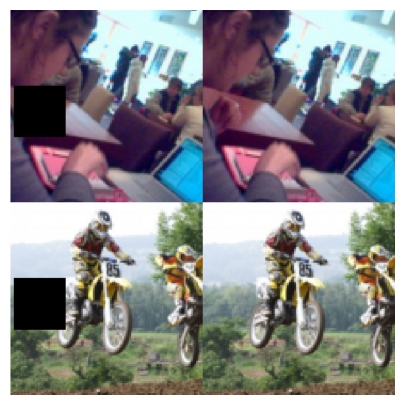

In [18]:
torch.manual_seed(1)
sample = next(iter(test_dataloader))[0]
sample = sample.permute(1, 2, 0)

plt.rcParams['figure.figsize'] = [5, 5]
show_image(sample)

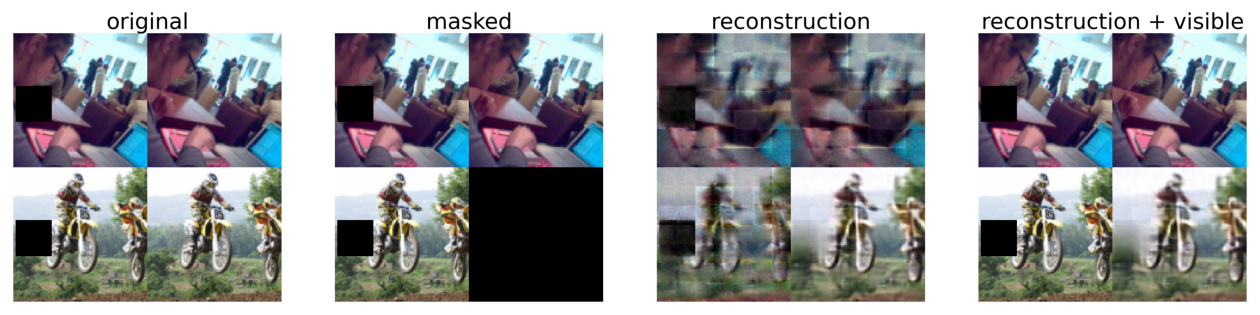

In [20]:
run_one_image(sample, generator, mask_ratio=0.75)

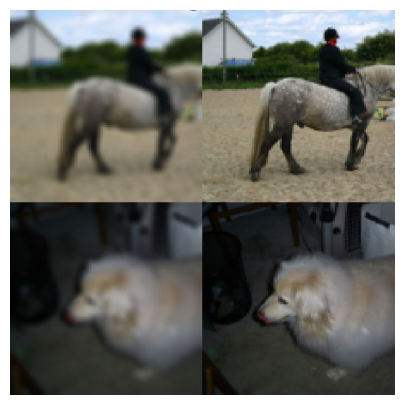

In [22]:
torch.manual_seed(1)
sample = next(iter(test_dataloader))[1]
sample = sample.permute(1, 2, 0)

plt.rcParams['figure.figsize'] = [5, 5]
show_image(sample)

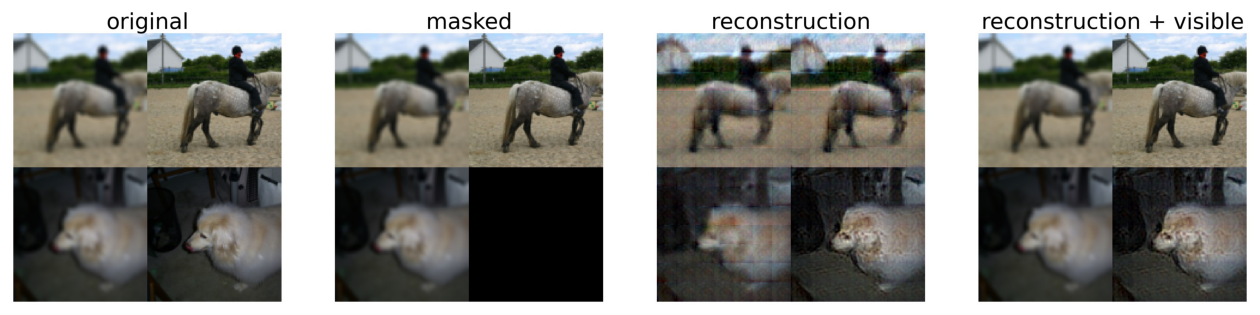

In [25]:
run_one_image(sample, generator, mask_ratio=0.75)

In [26]:
plt.close()